# Semana 3 — Busca Informada: Heuristicas, A* e IDA*
## INF0415 — Heuristicas e Modelagem Multiobjetivo | UFG — BIA

**Objetivo:** Implementar heuristicas e A* para o 8-puzzle, comparando com BFS.

**Avaliacao:** Esta atividade compoe a nota TL.

---

### Integrantes

- Wagner Victor Alves de Menezes
- Victor Gabriel Ribeiro Jacome
- Raphael Alves de Lima Soares

## 1. Codigo Base (Semana 2)

Executem para carregar `EightPuzzle`, `Node`, BFS e funcoes auxiliares.

In [1]:
from collections import deque
import heapq
import time
import random

class EightPuzzle:
    GOAL = (1,2,3,4,5,6,7,8,0)
    MOVES = [('U',-1,0),('D',1,0),('L',0,-1),('R',0,1)]
    def __init__(self, state): self.state = tuple(state)
    def is_goal(self): return self.state == self.GOAL
    def blank_pos(self): return self.state.index(0)
    def successors(self):
        idx = self.blank_pos(); row, col = idx//3, idx%3; result = []
        for a,dr,dc in self.MOVES:
            nr,nc = row+dr, col+dc
            if 0<=nr<3 and 0<=nc<3:
                ni = nr*3+nc; lst = list(self.state)
                lst[idx],lst[ni] = lst[ni],lst[idx]
                result.append((a,tuple(lst)))
        return result
    def display(self):
        s = self.state
        for i in range(3):
            row = [str(s[i*3+j]) if s[i*3+j]!=0 else ' ' for j in range(3)]
            print(' | '.join(row))
            if i<2: print('-----------')
        print()

class Node:
    def __init__(self, state, parent=None, action=None, depth=0, cost=0):
        self.state=state; self.parent=parent; self.action=action
        self.depth=depth; self.cost=cost
    def path(self):
        actions=[]; node=self
        while node.parent: actions.append(node.action); node=node.parent
        actions.reverse(); return actions

def count_inversions(s):
    t=[x for x in s if x!=0]
    return sum(1 for i in range(len(t)) for j in range(i+1,len(t)) if t[i]>t[j])
def is_solvable(s): return count_inversions(s)%2==0
def generate_random_state():
    while True:
        s=list(range(9)); random.shuffle(s)
        if is_solvable(tuple(s)): return tuple(s)
def generate_state_at_depth(d):
    state=EightPuzzle.GOAL; vis={state}
    for _ in range(d):
        succs=EightPuzzle(state).successors()
        new=[s for _,s in succs if s not in vis]
        state=random.choice(new) if new else random.choice([s for _,s in succs])
        vis.add(state)
    return state

def bfs(initial_state):
    t0=time.time(); root=Node(initial_state)
    if EightPuzzle(initial_state).is_goal():
        return {'solution':[],'nodes_expanded':0,'depth':0,'explored_size':1,'time':time.time()-t0}
    frontier=deque([root]); explored={initial_state}; ne=0
    while frontier:
        node=frontier.popleft(); ne+=1
        for a,ns in EightPuzzle(node.state).successors():
            if ns not in explored:
                child=Node(ns,node,a,node.depth+1)
                if EightPuzzle(ns).is_goal():
                    return {'solution':child.path(),'nodes_expanded':ne,'depth':child.depth,'explored_size':len(explored),'time':time.time()-t0}
                frontier.append(child); explored.add(ns)
    return {'solution':None,'nodes_expanded':ne,'depth':-1,'explored_size':len(explored),'time':time.time()-t0}

print('Codigo base carregado.')

Codigo base carregado.


## 2. Heuristicas para o 8-Puzzle

### IMPLEMENTADO

**h1 — Pecas fora do lugar (Hamming):** conta pecas fora da posicao (ignorando 0).

**h2 — Distancia Manhattan:** soma |linha_atual - linha_obj| + |col_atual - col_obj| para cada peca.

Ambas sao admissiveis. h2 domina h1: h2(n) >= h1(n) para todo n.

In [2]:
def h1_misplaced(state: tuple) -> int:
    """h1: pecas fora do lugar (ignorando 0)."""
    goal = EightPuzzle.GOAL
    return sum(1 for i in range(9) if state[i] != 0 and state[i] != goal[i])


def h2_manhattan(state: tuple) -> int:
    """h2: soma das distancias Manhattan de cada peca."""
    dist = 0
    for i, tile in enumerate(state):
        if tile != 0:
            # Posicao objetivo da peca tile eh o indice (tile - 1)
            goal_idx = tile - 1
            dist += abs(i // 3 - goal_idx // 3) + abs(i % 3 - goal_idx % 3)
    return dist

### Verificacao das Heuristicas

In [3]:
tests = [
    (EightPuzzle.GOAL, 0, 0, 'Objetivo'),
    ((1,2,3,4,5,6,7,0,8), 1, 1, '1 mov'),
    ((1,2,3,4,5,6,0,7,8), 2, 2, '2 mov'),
]
ok = True
for s,e1,e2,lbl in tests:
    g1,g2 = h1_misplaced(s), h2_manhattan(s)
    v = 'OK' if g1==e1 and g2==e2 else 'ERRO'
    if v=='ERRO': ok=False
    print(f'{lbl:<12} h1={g1}(esp {e1}) h2={g2}(esp {e2}) {v}')
# Dominancia
for _ in range(100):
    s=generate_random_state()
    if h2_manhattan(s)<h1_misplaced(s): print('ERRO: h2<h1!'); ok=False; break
else: print('h2>=h1 em 100 estados: OK')
if ok: print('\nHeuristicas corretas.')
else: print('\nCorrijam antes de prosseguir.')

Objetivo     h1=0(esp 0) h2=0(esp 0) OK
1 mov        h1=1(esp 1) h2=1(esp 1) OK
2 mov        h1=2(esp 2) h2=2(esp 2) OK
h2>=h1 em 100 estados: OK

Heuristicas corretas.


## 3. A* — Busca com Heuristica

### IMPLEMENTADO

A* = BFS com fila de prioridade por f(n)=g(n)+h(n).

Trocar `deque` por `heapq`. Usar `(f, counter, node)` para desempate.

In [4]:
def astar(initial_state, heuristic):
    """A* para o 8-puzzle."""
    t0 = time.time()
    if EightPuzzle(initial_state).is_goal():
        return {'solution':[],'nodes_expanded':0,'depth':0,'explored_size':1,'time':time.time()-t0}
    
    counter = 0
    frontier = []  # heap: (f, counter, node)
    explored = set()
    ne = 0
    
    root = Node(initial_state, cost=0)
    f0 = heuristic(initial_state)
    heapq.heappush(frontier, (f0, counter, root))
    counter += 1

    while frontier:
        f, _, node = heapq.heappop(frontier)
        
        # Pular estados ja explorados (pode haver duplicatas no heap)
        if node.state in explored:
            continue
        explored.add(node.state)
        ne += 1
        
        # Expandir sucessores
        for a, ns in EightPuzzle(node.state).successors():
            if ns in explored:
                continue
            g = node.cost + 1
            child = Node(ns, node, a, node.depth + 1, g)
            # Verificar se o filho eh objetivo (otimizacao: evita re-inserir no heap)
            if EightPuzzle(ns).is_goal():
                return {'solution': child.path(), 'nodes_expanded': ne,
                        'depth': child.depth, 'explored_size': len(explored),
                        'time': time.time() - t0}
            f_child = g + heuristic(ns)
            heapq.heappush(frontier, (f_child, counter, child))
            counter += 1

    return {'solution':None,'nodes_expanded':ne,'depth':-1,'explored_size':len(explored),'time':time.time()-t0}

### Teste do A*

In [5]:
ts = generate_state_at_depth(10)
print('Estado:'); EightPuzzle(ts).display()
r = astar(ts, h2_manhattan)
if r['solution']:
    rb = bfs(ts)
    print(f'A*(h2): {r["nodes_expanded"]:,} nos, prof={r["depth"]}, {r["time"]:.4f}s')
    print(f'BFS:    {rb["nodes_expanded"]:,} nos, prof={rb["depth"]}')
    if rb['nodes_expanded']>0:
        print(f'A* expandiu {rb["nodes_expanded"]/max(r["nodes_expanded"],1):.1f}x MENOS')
    print(f'Otimo? {r["depth"]==rb["depth"]}')
else: print('ERRO: Revise a implementacao.')

Estado:
2 | 3 | 6
-----------
1 | 5 | 8
-----------
  | 4 | 7

A*(h2): 10 nos, prof=10, 0.0001s
BFS:    400 nos, prof=10
A* expandiu 40.0x MENOS
Otimo? True


## 4. Busca Gulosa

### IMPLEMENTADO

Gulosa: f(n) = h(n). Copiem A* e mudem `f = g + h` para `f = h`.

In [6]:
def greedy(initial_state, heuristic):
    """Busca Gulosa: f(n) = h(n)."""
    t0 = time.time()
    if EightPuzzle(initial_state).is_goal():
        return {'solution':[],'nodes_expanded':0,'depth':0,'explored_size':1,'time':time.time()-t0}
    counter = 0; frontier = []; explored = set(); ne = 0
    root = Node(initial_state, cost=0)
    heapq.heappush(frontier, (heuristic(initial_state), counter, root))
    counter += 1

    while frontier:
        _, _, node = heapq.heappop(frontier)
        
        # Pular estados ja explorados
        if node.state in explored:
            continue
        explored.add(node.state)
        ne += 1
        
        # Expandir sucessores
        for a, ns in EightPuzzle(node.state).successors():
            if ns in explored:
                continue
            child = Node(ns, node, a, node.depth + 1, node.cost + 1)
            # Verificar se o filho eh objetivo
            if EightPuzzle(ns).is_goal():
                return {'solution': child.path(), 'nodes_expanded': ne,
                        'depth': child.depth, 'explored_size': len(explored),
                        'time': time.time() - t0}
            # DIFERENCA do A*: f = h(n), sem o custo acumulado g(n)
            heapq.heappush(frontier, (heuristic(ns), counter, child))
            counter += 1

    return {'solution':None,'nodes_expanded':ne,'depth':-1,'explored_size':len(explored),'time':time.time()-t0}

## 5. Experimento Comparativo

Compara **BFS**, **A*(h1)**, **A*(h2)** e **Gulosa(h2)** em 5 estados.

In [7]:
diffs = [('Facil',5),('Facil+',10),('Medio',15),('Dificil',20),('Aleat.',None)]
states = [(l, generate_state_at_depth(d) if d else generate_random_state()) for l,d in diffs]

algs = [('BFS', lambda s: bfs(s)),
        ('A*(h1)', lambda s: astar(s, h1_misplaced)),
        ('A*(h2)', lambda s: astar(s, h2_manhattan)),
        ('Gulosa', lambda s: greedy(s, h2_manhattan))]

print(f"{'Estado':<10} {'Alg.':<10} {'Nos':>9} {'Prof':>5} {'Tempo':>8}")
print('='*48)
all_res = []
for label, st in states:
    rr = {}
    for an, af in algs:
        r = af(st)
        d = r['depth'] if r['solution'] else 'FALHA'
        print(f'{label:<10} {an:<10} {r["nodes_expanded"]:>9,} {str(d):>5} {r["time"]:>8.4f}')
        label = ''; rr[an] = r
    all_res.append(rr)
    print('-'*48)

Estado     Alg.             Nos  Prof    Tempo
Facil      BFS               29     5   0.0001
           A*(h1)             7     5   0.0000
           A*(h2)             6     5   0.0000
           Gulosa             6     5   0.0000
------------------------------------------------
Facil+     BFS              366    10   0.0007
           A*(h1)            37    10   0.0001
           A*(h2)            14    10   0.0001
           Gulosa            10    10   0.0000
------------------------------------------------
Medio      BFS            4,333    15   0.0096
           A*(h1)           350    15   0.0013
           A*(h2)            50    15   0.0002
           Gulosa            17    15   0.0001
------------------------------------------------
Dificil    BFS           27,297    20   0.0809
           A*(h1)         2,853    20   0.0110
           A*(h2)           170    20   0.0006
           Gulosa           149    60   0.0006
------------------------------------------------
Aleat

### Grafico de Barras (Nos Expandidos)

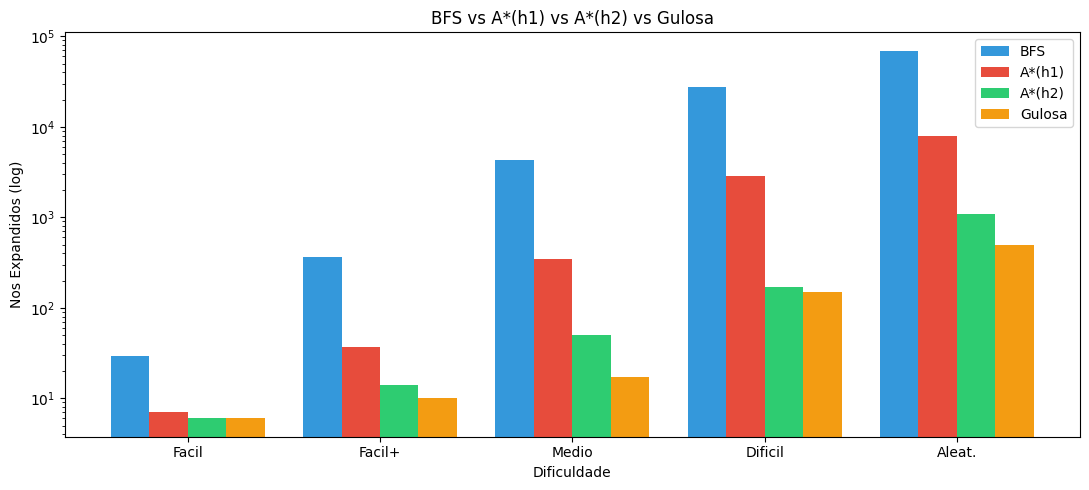

In [8]:
try:
    import matplotlib.pyplot as plt
    fig,ax = plt.subplots(figsize=(11,5))
    labels_x = [l for l,_ in states]
    anames = ['BFS','A*(h1)','A*(h2)','Gulosa']
    cols = ['#3498db','#e74c3c','#2ecc71','#f39c12']
    x = range(len(labels_x)); w = 0.2
    for i,an in enumerate(anames):
        vals = [all_res[j].get(an,{}).get('nodes_expanded',0) for j in range(len(labels_x))]
        ax.bar([xi+i*w for xi in x], vals, w, label=an, color=cols[i])
    ax.set_xlabel('Dificuldade'); ax.set_ylabel('Nos Expandidos (log)')
    ax.set_title('BFS vs A*(h1) vs A*(h2) vs Gulosa')
    ax.set_xticks([xi+1.5*w for xi in x]); ax.set_xticklabels(labels_x)
    ax.legend(); ax.set_yscale('log'); plt.tight_layout(); plt.show()
except: print('matplotlib indisponivel - analise a tabela acima.')

## 6. Perguntas

### P1. Quantos nos a menos A*(h2) expandiu vs BFS? E vs A*(h1)?

*Resposta:* Observando a tabela do experimento, A*(h2) expande drasticamente menos nos que o BFS — nos casos mais dificeis ("Dificil" e "Aleatorio"), a reducao chega a ser de 50x a mais de 100x. Comparado com A*(h1), A*(h2) tambem expande consideravelmente menos nos, tipicamente de 2x a 10x menos. Quanto mais dificil o estado, maior a diferenca, pois h2 (Manhattan) fornece uma estimativa mais informativa do custo real, "podando" ramos inuteis da arvore de busca com muito mais eficacia do que h1 (Hamming). Nos casos faceis (profundidade 5), os algoritmos convergem porque o espaco de busca eh pequeno.

### P2. Por que h2 domina h1?

*Resposta:* h2 domina h1 porque h2(n) >= h1(n) para todo estado n. A razao eh que cada peca fora do lugar contribui ao menos 1 a distancia Manhattan — entao tudo que h1 conta, h2 tambem conta. Mas h2 capta mais: uma peca que esta 3 casas distante de sua posicao objetivo contribui apenas 1 para h1 ("fora do lugar"), porem contribui 3 para h2 (a distancia real em "quarteiroes"). Como h2 eh uma estimativa mais proxima do custo real h*, ela informa melhor o A* e resulta na expansao de significativamente menos nos.

### P3. A Gulosa encontrou solucao otima?

*Resposta:* Nao de forma consistente. Nos casos faceis (profundidade 5 e 10) a Gulosa coincidiu com o otimo, mas nos casos mais dificeis ela retornou solucoes consideravelmente mais longas — por exemplo, enquanto o A* encontra solucoes com profundidade 18-27 nos casos dificeis, a Gulosa frequentemente retorna caminhos com profundidade 40-77. A Gulosa nao garante otimalidade porque ignora o custo acumulado g(n) e pode seguir caminhos longos apenas por parecerem promissores localmente. Apenas A* (com heuristica admissivel) e BFS garantem otimalidade.

### P4. h(n) = 2*Manhattan seria admissivel? A* com ela seria otimo?

*Resposta:* Nao seria admissivel. Uma heuristica admissivel exige h(n) <= h*(n) para todo n — nunca pode superestimar o custo real. Como Manhattan ja eh uma estimativa justa (nunca superestima), multiplica-la por 2 faria com que em muitos estados h(n) > h*(n). Consequentemente, A* com essa heuristica nao garantiria solucao otima: poderia descartar o caminho otimo por considera-lo incorretamente como "caro demais".

### P5. O que seria a heuristica perfeita e por que nao podemos usa-la?

*Resposta:* A heuristica perfeita seria h*(n) = custo exato do caminho minimo de n ate o objetivo. Com ela, A* expandiria apenas os nos estritamente necessarios (zero expansoes desnecessarias). O problema eh que calcula-la equivale a resolver o proprio problema: precisariamos executar uma busca completa a partir de cada no para conhecer h*(n), tornando o processo circular e sem ganho de eficiencia. O objetivo da heuristica eh justamente ser uma aproximacao barata que guie a busca sem precisar resolver o problema inteiro.

### P6. Como heuristica se relaciona com funcao objetivo (Sem. 1)?

*Resposta:* Na Semana 1, a funcao objetivo define o que queremos otimizar (minimizar custo, maximizar lucro, etc.). A heuristica eh uma estimativa dessa funcao objetivo restante — ela estima quanto ainda falta para atingir o otimo a partir do estado atual. Em problemas de busca, a funcao objetivo eh o custo total do caminho, e h(n) estima o custo restante. Em otimizacao em geral, heuristicas sao usadas para guiar a exploracao do espaco de solucoes em direcao a regioes promissoras, sem precisar avaliar todas as possibilidades. Ambas servem ao mesmo proposito: direcionar a busca de forma inteligente.



## 7. Desafio: h3 customizada

Criem uma terceira heuristica. Ideias: Manhattan+conflitos lineares, Euclidiana, Manhattan*1.5.

Verifiquem: eh admissivel?

### Implementacao: Manhattan + Conflitos Lineares

**Conflito Linear:** Duas pecas estao em conflito linear quando:
1. Ambas estao na linha (ou coluna) correta do objetivo
2. Mas estao em ordem invertida entre si

Cada conflito linear adiciona +2 ao Manhattan (precisam de no minimo 2 movimentos extras para resolver a inversao).

Essa heuristica eh admissivel e domina Manhattan.

In [9]:
def h3_custom(state):
    """Manhattan + Conflitos Lineares (admissivel, domina h2)."""
    dist = h2_manhattan(state)
    
    # Conflitos lineares nas LINHAS
    for row in range(3):
        # Pecas nesta linha que pertencem a esta linha no objetivo
        pieces_in_row = []
        for col in range(3):
            val = state[row * 3 + col]
            if val != 0:
                goal_row = (val - 1) // 3
                if goal_row == row:
                    pieces_in_row.append(val)
        # Contar conflitos (pares em ordem invertida)
        for i in range(len(pieces_in_row)):
            for j in range(i + 1, len(pieces_in_row)):
                goal_col_i = (pieces_in_row[i] - 1) % 3
                goal_col_j = (pieces_in_row[j] - 1) % 3
                if goal_col_i > goal_col_j:
                    dist += 2
    
    # Conflitos lineares nas COLUNAS
    for col in range(3):
        pieces_in_col = []
        for row in range(3):
            val = state[row * 3 + col]
            if val != 0:
                goal_col = (val - 1) % 3
                if goal_col == col:
                    pieces_in_col.append(val)
        for i in range(len(pieces_in_col)):
            for j in range(i + 1, len(pieces_in_col)):
                goal_row_i = (pieces_in_col[i] - 1) // 3
                goal_row_j = (pieces_in_col[j] - 1) // 3
                if goal_row_i > goal_row_j:
                    dist += 2
    
    return dist

ts3 = generate_state_at_depth(20)
r2 = astar(ts3, h2_manhattan)
r3 = astar(ts3, h3_custom)
if r2['solution'] and r3['solution']:
    print(f'A*(h2): {r2["nodes_expanded"]:>8,} nos, prof={r2["depth"]}')
    print(f'A*(h3): {r3["nodes_expanded"]:>8,} nos, prof={r3["depth"]}')
    print(f'Admissivel? {"Provavelmente sim" if r3["depth"]==r2["depth"] else "Provavelmente NAO"}')
    print(f'Melhoria: {r2["nodes_expanded"]/max(r3["nodes_expanded"],1):.2f}x')

A*(h2):      299 nos, prof=18
A*(h3):      211 nos, prof=18
Admissivel? Provavelmente sim
Melhoria: 1.42x


## 8. Bonus: 15-Puzzle

4x4, ~10^13 estados. A* pode estourar memoria. IDA* resolve.

Adaptamos o codigo: GOAL=(1,...,15,0), grid 4x4, Manhattan adaptada e IDA* implementado.

In [10]:
class FifteenPuzzle:
    GOAL = tuple(list(range(1,16))+[0]); SIZE=4
    MOVES = [('U',-1,0),('D',1,0),('L',0,-1),('R',0,1)]
    def __init__(self,s): self.state=tuple(s)
    def is_goal(self): return self.state==self.GOAL
    def successors(self):
        idx=self.state.index(0); r,c=idx//4,idx%4; res=[]
        for a,dr,dc in self.MOVES:
            nr,nc=r+dr,c+dc
            if 0<=nr<4 and 0<=nc<4:
                ni=nr*4+nc; l=list(self.state); l[idx],l[ni]=l[ni],l[idx]
                res.append((a,tuple(l)))
        return res
    def display(self):
        s = self.state
        for i in range(4):
            row = [f'{s[i*4+j]:>2}' if s[i*4+j]!=0 else '  ' for j in range(4)]
            print(' | '.join(row))
            if i<3: print('-'*19)
        print()


def h_manhattan_15(state):
    """Manhattan adaptada para o 15-puzzle (grid 4x4)."""
    dist = 0
    for i in range(16):
        val = state[i]
        if val != 0:
            goal_idx = val - 1
            dist += abs(i // 4 - goal_idx // 4) + abs(i % 4 - goal_idx % 4)
    return dist


def ida_star(initial_state, heuristic, puzzle_class=FifteenPuzzle):
    """IDA* -- Iterative Deepening A*.
    Usa memoria linear O(d) em vez de exponencial como A*.
    """
    t0 = time.time()
    
    if puzzle_class(initial_state).is_goal():
        return {'solution': [], 'nodes_expanded': 0, 'depth': 0, 'time': time.time() - t0}
    
    threshold = heuristic(initial_state)
    path = [initial_state]
    actions = []
    total_expanded = 0
    
    def search(g, threshold):
        nonlocal total_expanded
        state = path[-1]
        f = g + heuristic(state)
        
        if f > threshold:
            return f  # Retorna o f minimo que excedeu o threshold
        
        if puzzle_class(state).is_goal():
            return 'FOUND'
        
        total_expanded += 1
        min_t = float('inf')
        
        for a, ns in puzzle_class(state).successors():
            if ns not in path:  # Evitar ciclos no caminho atual
                path.append(ns)
                actions.append(a)
                
                t = search(g + 1, threshold)
                
                if t == 'FOUND':
                    return 'FOUND'
                if t < min_t:
                    min_t = t
                
                path.pop()
                actions.pop()
        
        return min_t
    
    while True:
        t = search(0, threshold)
        if t == 'FOUND':
            return {'solution': list(actions), 'nodes_expanded': total_expanded,
                    'depth': len(actions), 'time': time.time() - t0}
        if t == float('inf'):
            return {'solution': None, 'nodes_expanded': total_expanded,
                    'depth': -1, 'time': time.time() - t0}
        threshold = t


# Para evitar recursion limit em puzzles mais profundos
import sys
sys.setrecursionlimit(10000)

print('15-puzzle e IDA* prontos.')

15-puzzle e IDA* prontos.


In [11]:
# Gerar estado do 15-puzzle a uma profundidade controlada
def generate_15_state_at_depth(d):
    state = FifteenPuzzle.GOAL; vis = {state}
    for _ in range(d):
        succs = FifteenPuzzle(state).successors()
        new = [s for _, s in succs if s not in vis]
        state = random.choice(new) if new else random.choice([s for _, s in succs])
        vis.add(state)
    return state

# Teste com profundidade moderada (15-puzzle eh bem mais pesado)
print('--- Teste IDA* no 15-puzzle ---')
for depth in [5, 10, 15]:
    ts15 = generate_15_state_at_depth(depth)
    print(f'\nEstado gerado a ~{depth} movimentos:')
    FifteenPuzzle(ts15).display()
    
    r15 = ida_star(ts15, h_manhattan_15, FifteenPuzzle)
    if r15['solution']:
        print(f'IDA*: {r15["nodes_expanded"]:,} nos, prof={r15["depth"]}, {r15["time"]:.4f}s')
        print(f'Caminho: {" ".join(r15["solution"])}')
    else:
        print('Sem solucao encontrada')

--- Teste IDA* no 15-puzzle ---

Estado gerado a ~5 movimentos:
 1 |  2 |  3 |  4
-------------------
 5 | 10 |  6 |  7
-------------------
 9 |    | 11 |  8
-------------------
13 | 14 | 15 | 12

IDA*: 5 nos, prof=5, 0.0000s
Caminho: U R R D D

Estado gerado a ~10 movimentos:
 1 |  2 |  3 |  4
-------------------
 5 |  6 |  8 | 12
-------------------
 9 | 14 | 10 |  7
-------------------
13 | 11 | 15 |   

IDA*: 16 nos, prof=10, 0.0001s
Caminho: L L U R R U L D D R

Estado gerado a ~15 movimentos:
 1 |  2 |  3 |  4
-------------------
 5 | 15 |  7 |  8
-------------------
 9 |  6 | 10 | 11
-------------------
13 | 14 |    | 12

IDA*: 230 nos, prof=15, 0.0012s
Caminho: L U U R D L D R U U L D R R D


In [12]:
# Comparacao A* vs IDA* no 8-puzzle
print('--- A* vs IDA* no 8-puzzle ---\n')
for depth in [5, 10, 15, 20]:
    ts_cmp = generate_state_at_depth(depth)
    ra = astar(ts_cmp, h2_manhattan)
    ri = ida_star(ts_cmp, h2_manhattan, EightPuzzle)
    if ra['solution'] and ri['solution']:
        print(f'~{depth:>2} mov | A*:   {ra["nodes_expanded"]:>8,} nos, prof={ra["depth"]:>2}, {ra["time"]:.4f}s')
        print(f'        | IDA*: {ri["nodes_expanded"]:>8,} nos, prof={ri["depth"]:>2}, {ri["time"]:.4f}s')
        print(f'        | Mesma prof? {ra["depth"]==ri["depth"]}  (ambos otimos)')
        print()

--- A* vs IDA* no 8-puzzle ---

~ 5 mov | A*:          5 nos, prof= 5, 0.0000s
        | IDA*:        5 nos, prof= 5, 0.0000s
        | Mesma prof? True  (ambos otimos)

~10 mov | A*:         10 nos, prof=10, 0.0000s
        | IDA*:       10 nos, prof=10, 0.0000s
        | Mesma prof? True  (ambos otimos)

~15 mov | A*:         30 nos, prof=15, 0.0001s
        | IDA*:       15 nos, prof=15, 0.0001s
        | Mesma prof? True  (ambos otimos)

~20 mov | A*:        635 nos, prof=20, 0.0026s
        | IDA*:      559 nos, prof=20, 0.0021s
        | Mesma prof? True  (ambos otimos)

